# ARTIFICIAL NEURAL NETWORKS

#### Case Study: SONAR — Detecting Mines vs. Rocks

In [46]:
!pip install keras

In [47]:
!pip install scikeras

In [48]:
!pip install tensorflow

### 1. Data Exploration and Preprocessing

In [49]:
import keras
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split,GridSearchCV
import warnings
warnings.filterwarnings('ignore')

In [50]:
df=pd.read_csv('sonardataset.csv')
df.head()

,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_52,x_53,x_54,x_55,x_56,x_57,x_58,x_59,x_60,Y
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 61 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x_1     208 non-null    float64
 1   x_2     208 non-null    float64
 2   x_3     208 non-null    float64
 3   x_4     208 non-null    float64
 4   x_5     208 non-null    float64
 5   x_6     208 non-null    float64
 6   x_7     208 non-null    float64
 7   x_8     208 non-null    float64
 8   x_9     208 non-null    float64
 9   x_10    208 non-null    float64
 10  x_11    208 non-null    float64
 11  x_12    208 non-null    float64
 12  x_13    208 non-null    float64
 13  x_14    208 non-null    float64
 14  x_15    208 non-null    float64
 15  x_16    208 non-null    float64
 16  x_17    208 non-null    float64
 17  x_18    208 non-null    float64
 18  x_19    208 non-null    float64
 19  x_20    208 non-null    float64
 20  x_21    208 non-null    float64
 21  x_22    208 non-null    float64
 22  x_

In [52]:
df.describe()

,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_51,x_52,x_53,x_54,x_55,x_56,x_57,x_58,x_59,x_60
count,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,...,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000
mean,0.029164,0.038437,0.043832,0.053892,0.075202,0.104570,0.121747,0.134799,0.178003,0.208259,...,0.016069,0.013420,0.010709,0.010941,0.009290,0.008222,0.007820,0.007949,0.007941,0.006507
std,0.022991,0.032960,0.038428,0.046528,0.055552,0.059105,0.061788,0.085152,0.118387,0.134416,...,0.012008,0.009634,0.007060,0.007301,0.007088,0.005736,0.005785,0.006470,0.006181,0.005031
min,0.001500,0.000600,0.001500,0.005800,0.006700,0.010200,0.003300,0.005500,0.007500,0.011300,...,0.000000,0.000800,0.000500,0.001000,0.000600,0.000400,0.000300,0.000300,0.000100,0.000600
25%,0.013350,0.016450,0.018950,0.024375,0.038050,0.067025,0.080900,0.080425,0.097025,0.111275,...,0.008425,0.007275,0.005075,0.005375,0.004150,0.004400,0.003700,0.003600,0.003675,0.003100
50%,0.022800,0.030800,0.034300,0.044050,0.062500,0.092150,0.106950,0.112100,0.152250,0.182400,...,0.013900,0.011400,0.009550,0.009300,0.007500,0.006850,0.005950,0.005800,0.006400,0.005300
75%,0.035550,0.047950,0.057950,0.064500,0.100275,0.134125,0.154000,0.169600,0.233425,0.268700,...,0.020825,0.016725,0.014900,0.014500,0.012100,0.010575,0.010425,0.010350,0.010325,0.008525
max,0.137100,0.233900,0.305900,0.426400,0.401000,0.382300,0.372900,0.459000,0.682800,0.710600,...,0.100400,0.070900,0.039000,0.035200,0.044700,0.039400,0.035500,0.044000,0.036400,0.043900


In [53]:
df.shape

(208, 61)

In [54]:
## missing_value
df.isnull().sum().sum()

np.int64(0)

In [55]:
## duplicates
df.duplicated().sum()

np.int64(0)

Y
M    111
R     97
Name: count, dtype: int64


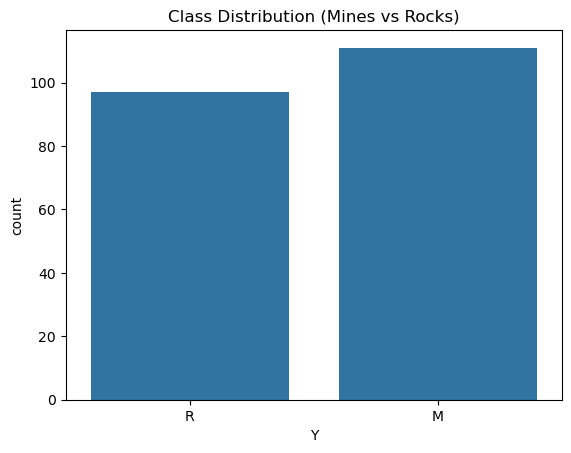

In [56]:
# class distribution
print(df['Y'].value_counts())
sns.countplot(x='Y', data=df)
plt.title("Class Distribution (Mines vs Rocks)")
plt.show()

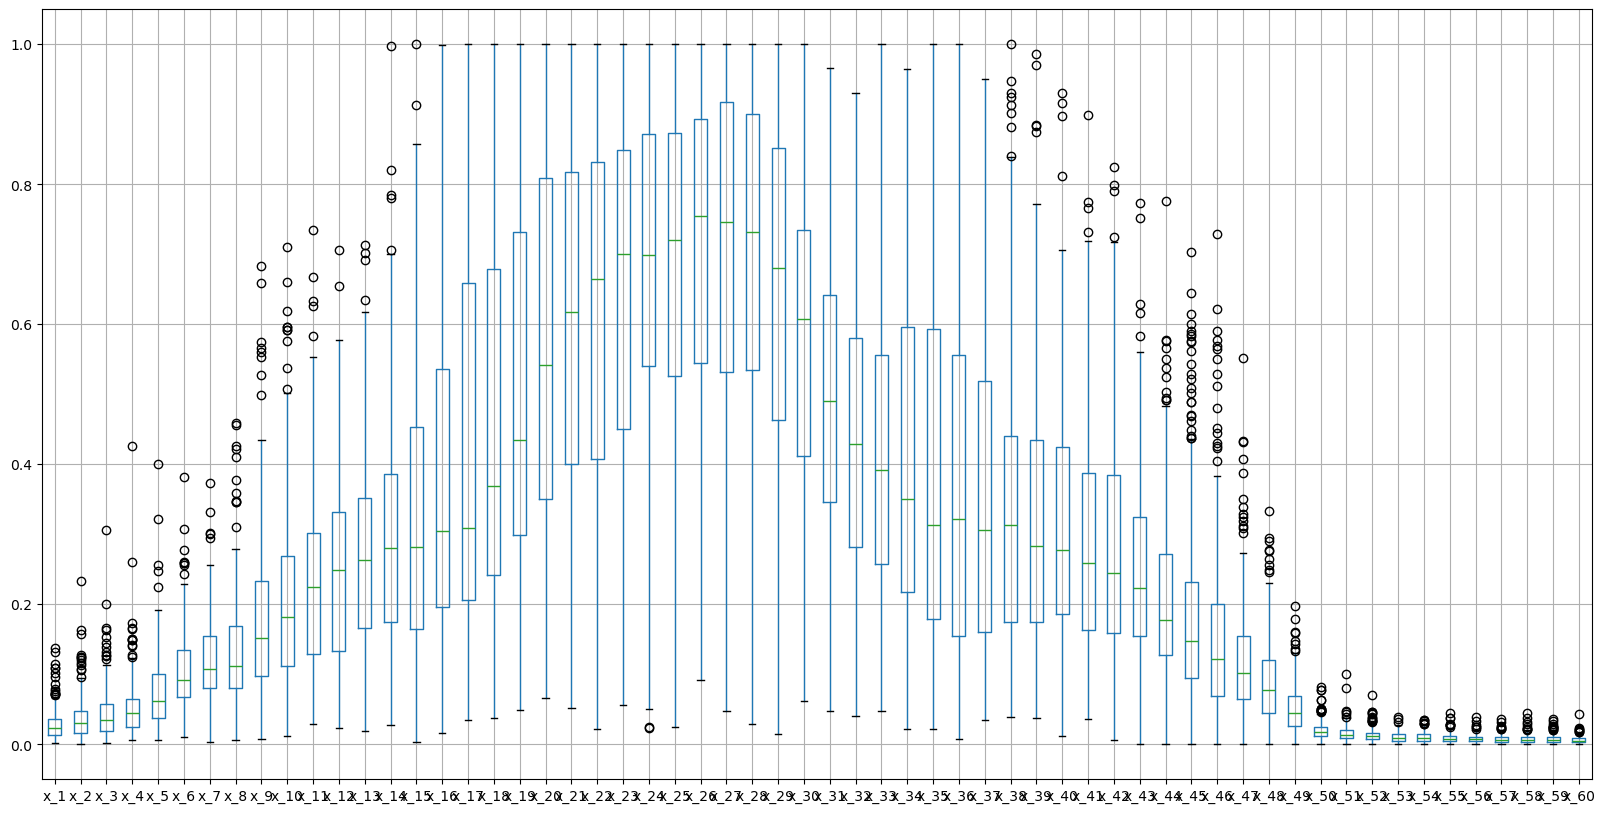

In [57]:
## boxplot
plt.figure(figsize=(20,10))
df.boxplot()
plt.show()

In [58]:
# encode target
df['Y'] = df['Y'].str.strip()
df['Y'] = df['Y'].map({'M': 1, 'R': 0})
df.head()

,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_52,x_53,x_54,x_55,x_56,x_57,x_58,x_59,x_60,Y
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,0
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,0
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,0
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,0
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,0


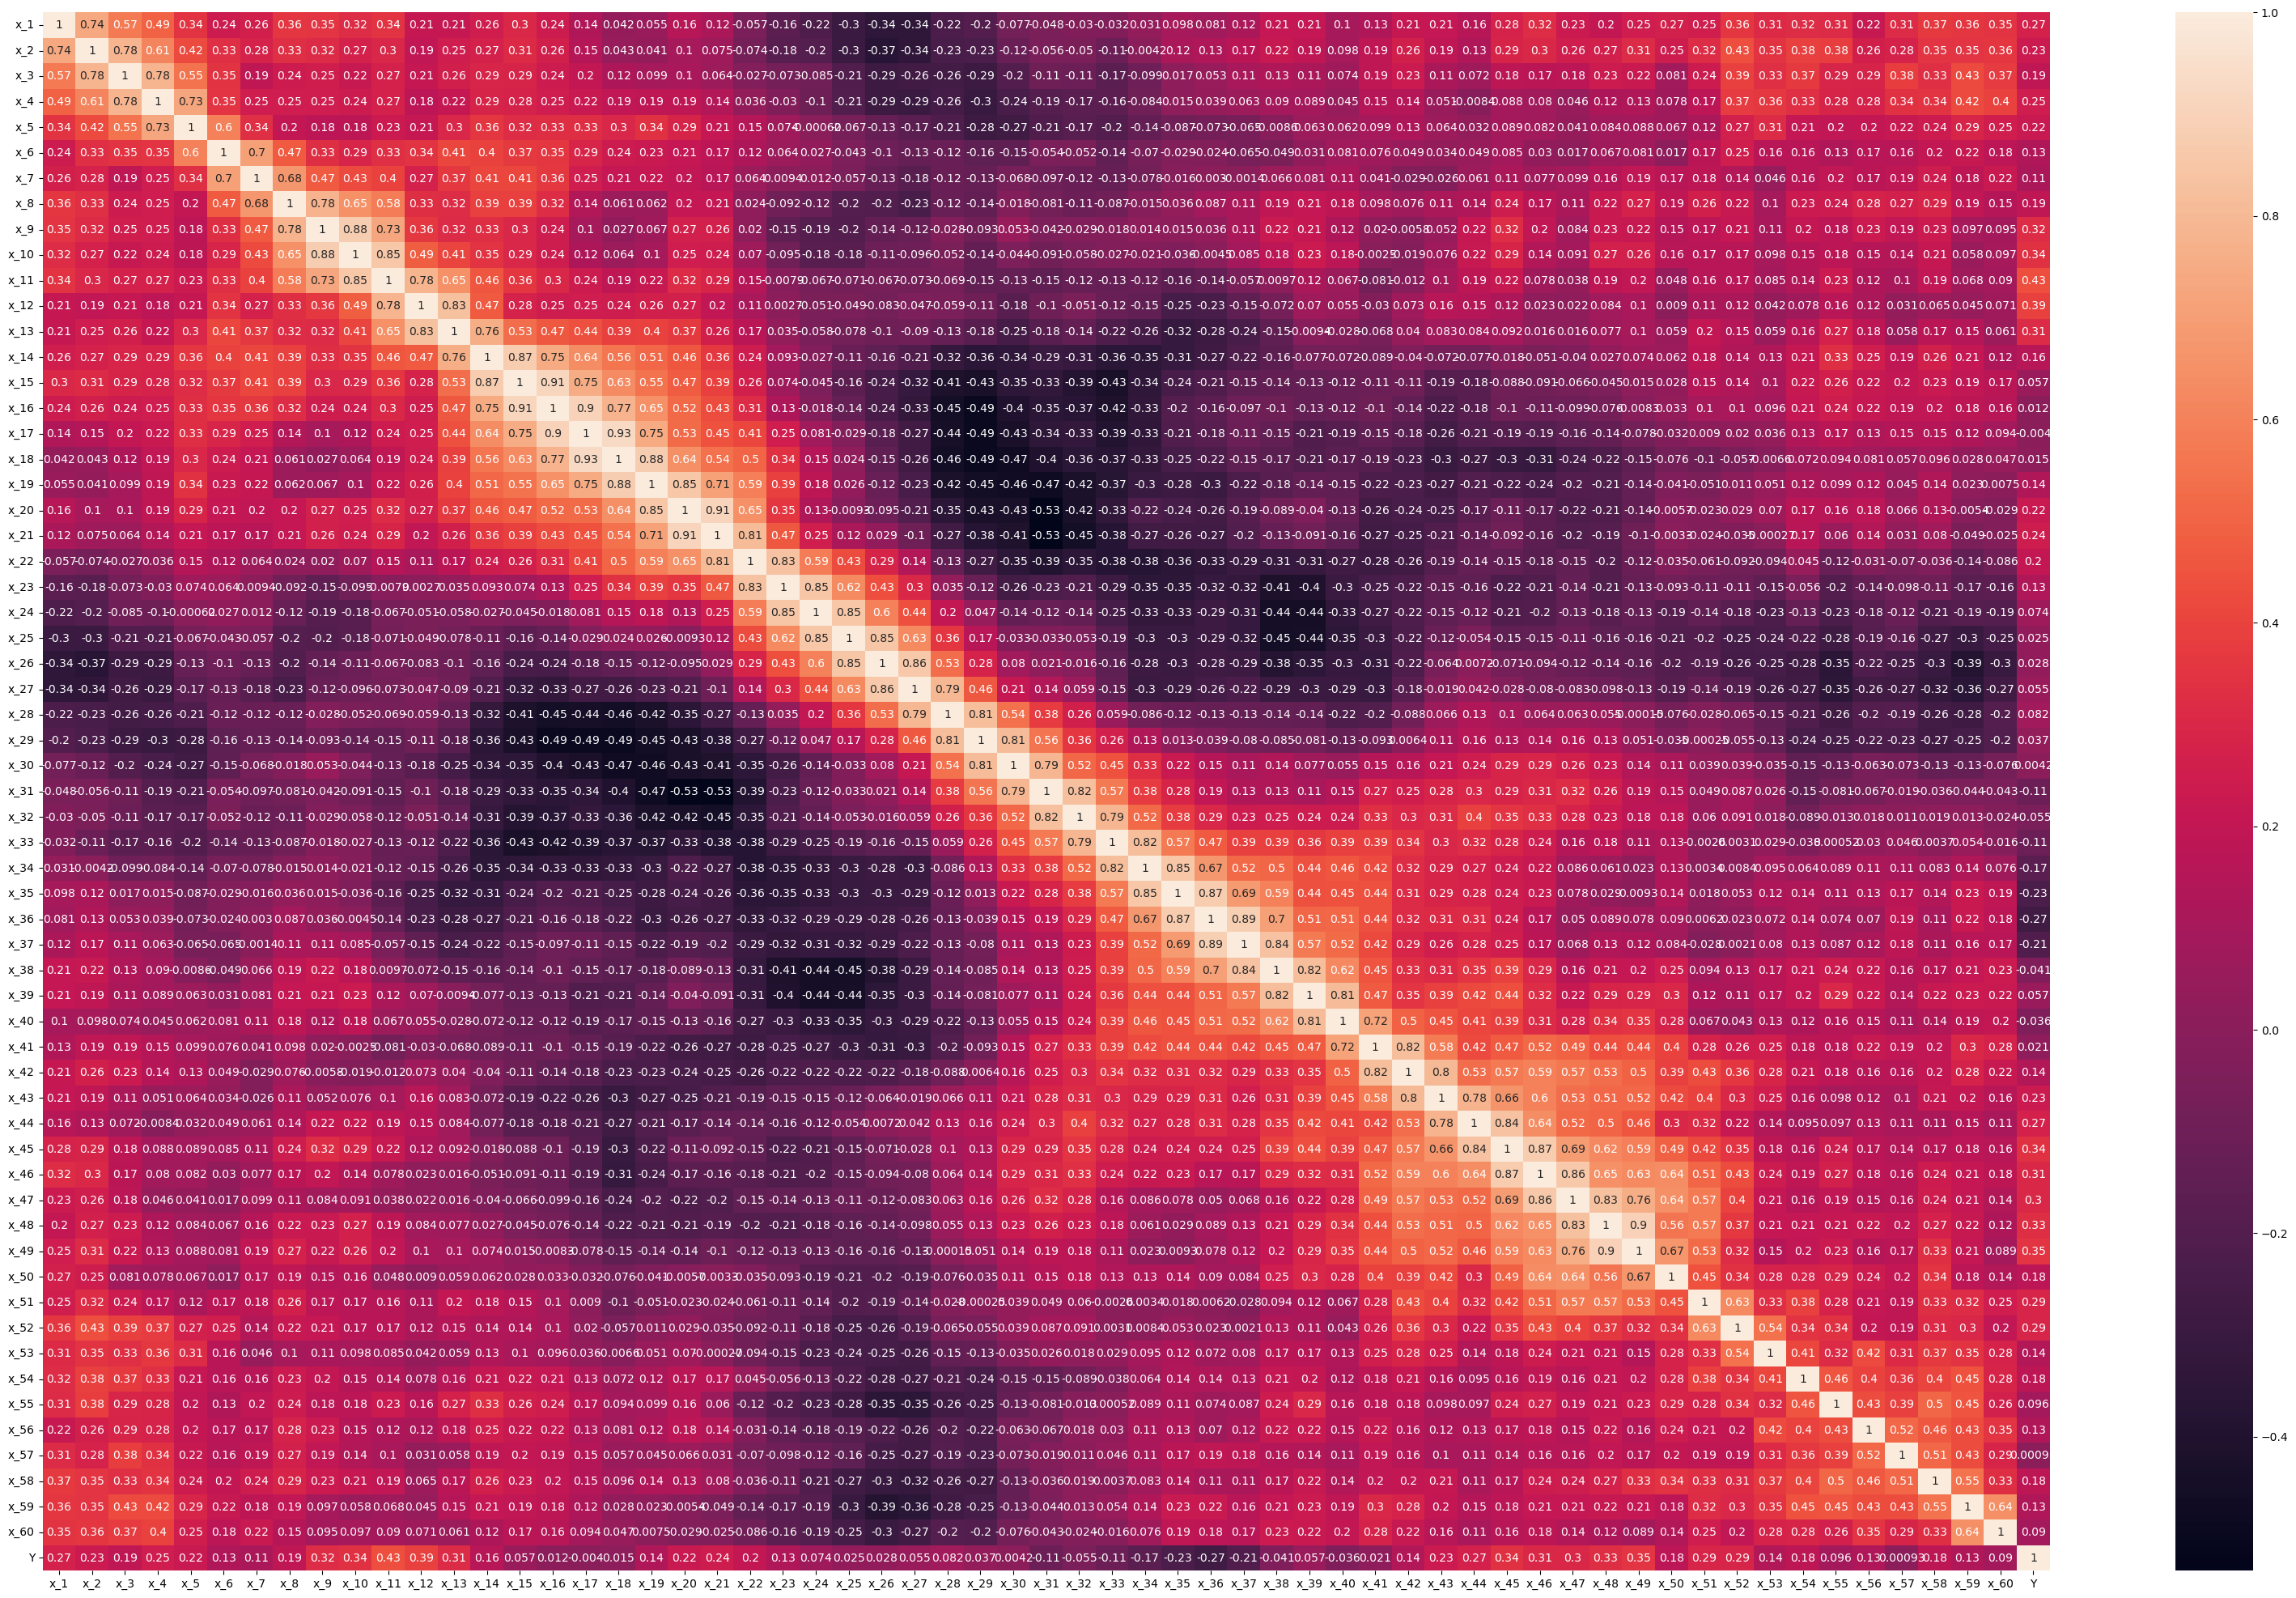

In [59]:
## correlation
plt.figure(figsize=(40,25))
corr=df.corr()
sns.heatmap(corr,annot=True)
plt.show()

In [60]:
## corr with target
corr_target = corr['Y'].drop('Y')
print('Positive :\n',corr_target.sort_values(ascending=False).head(2))
print('Negative:\n',corr_target.sort_values().head(2))

Positive :
 x_11    0.432855
x_12    0.392245
Name: Y, dtype: float64
Negative:
 x_36   -0.269151
x_35   -0.227670
Name: Y, dtype: float64


In [61]:
## corr with feature-feature
feature_corr = corr.iloc[:-1, :-1]
corr_pairs = feature_corr.unstack()
corr_pairs = corr_pairs[corr_pairs!= 1]
print('Max_corr:',corr_pairs[corr_pairs ==corr_pairs.max()])
print('Min_corr:',corr_pairs[corr_pairs ==corr_pairs.min()])

Max_corr: x_17  x_18    0.925836
x_18  x_17    0.925836
dtype: float64
Min_corr: x_21  x_31   -0.531777
x_31  x_21   -0.531777
dtype: float64


In [62]:
target=df['Y']
features=df.drop(columns=['Y'])

In [63]:
## Min Max Scaling
min_max=MinMaxScaler()
features_scaled=min_max.fit_transform(features)

### 2. Model Implementation

In [64]:
epochs=100
n_classes=2
batch_size=32

In [65]:
## ANN Model
ann=tf.keras.models.Sequential()
ann.add(tf.keras.layers.Dense(units=32,activation='relu',input_shape=[60]))
ann.add(tf.keras.layers.Dense(units=1,activation='sigmoid'))
ann.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                     │ (None, 32)                  │           1,952 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_21 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,985 (7.75 KB)

 Trainable params: 1,985 (7.75 KB)

 Non-trainable params: 0 (0.00 B)

In [66]:
ann.compile(optimizer=tf.keras.optimizers.Adam(),
              loss=tf.keras.losses.binary_crossentropy,metrics=['accuracy'])

In [67]:
## train test split
x_train,x_test,y_train,y_test=train_test_split(features_scaled,target,test_size=0.2,random_state=42,stratify=target)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(166, 60)
(42, 60)
(166,)
(42,)


In [68]:
history=ann.fit(x_train,y_train,epochs=epochs,batch_size=batch_size,validation_data=(x_test,y_test))

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 118ms/step - accuracy: 0.4880 - loss: 0.7057 - val_accuracy: 0.5238 - val_loss: 0.7095
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.5301 - loss: 0.6841 - val_accuracy: 0.5238 - val_loss: 0.7009
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5904 - loss: 0.6715 - val_accuracy: 0.5238 - val_loss: 0.6948
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.6205 - loss: 0.6608 - val_accuracy: 0.5476 - val_loss: 0.6880
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.6265 - loss: 0.6520 - val_accuracy: 0.5000 - val_loss: 0.6836
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.6446 - loss: 0.6443 - val_accuracy: 0.5476 - val_loss: 0.6765
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.6687 - loss: 0.6366 - val_accuracy: 0.5476 - val_loss: 0.6679
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.6747 - loss: 0.6283 - val_accuracy: 0.5476 - val_loss

In [69]:
loss,accuracy=ann.evaluate(x_test,y_test)
print('loss:',loss,'accuracy:',accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.7619 - loss: 0.4486
loss: 0.4485642611980438 accuracy: 0.761904776096344


### 3. Hyperparameter Tuning

In [70]:
import random

In [71]:
def build_model(neurons, layers, activation, lr):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Dense(neurons, activation=activation, input_shape=[60]))
    for _ in range(layers - 1):
        model.add(tf.keras.layers.Dense(neurons, activation=activation))
    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))
        
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),loss='binary_crossentropy',metrics=['accuracy'])
    return model

In [72]:
param_space = {"neurons": [16, 32, 64],"layers": [1, 2, 3],"activation": ["relu", "tanh"],"lr": [0.001, 0.01]}

In [73]:
results = []
n_search = 5
for i in range(n_search):
    neurons = random.choice(param_space["neurons"])
    layers = random.choice(param_space["layers"])
    activation = random.choice(param_space["activation"])
    lr = random.choice(param_space["lr"])
    
    print(f"\nRunning trial {i+1}: neurons={neurons}, layers={layers}, activation={activation}, lr={lr}")
    
    model = build_model(neurons, layers, activation, lr)
    model.fit(x_train, y_train, epochs=40, batch_size=16, verbose=0)
    loss, acc = model.evaluate(x_test, y_test, verbose=0)
    
    results.append({"neurons": neurons,"layers": layers,"activation": activation,"lr": lr,"accuracy": acc})


Running trial 1: neurons=64, layers=3, activation=tanh, lr=0.01

Running trial 2: neurons=32, layers=1, activation=relu, lr=0.01

Running trial 3: neurons=16, layers=1, activation=relu, lr=0.01

Running trial 4: neurons=64, layers=1, activation=relu, lr=0.01

Running trial 5: neurons=16, layers=1, activation=relu, lr=0.01


In [74]:
df_results = pd.DataFrame(results)
df_results

,neurons,layers,activation,lr,accuracy
0,64,3,tanh,0.01,0.833333
1,32,1,relu,0.01,0.785714
2,16,1,relu,0.01,0.833333
3,64,1,relu,0.01,0.833333
4,16,1,relu,0.01,0.809524


In [75]:
## ANN Model
best_model=tf.keras.models.Sequential()
best_model.add(tf.keras.layers.Dense(units=32,activation='tanh',input_shape=[60]))
best_model.add(tf.keras.layers.Dense(units=32,activation='tanh'))
best_model.add(tf.keras.layers.Dense(units=32,activation='tanh'))
best_model.add(tf.keras.layers.Dense(units=1,activation='sigmoid'))
best_model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_34 (Dense)                     │ (None, 32)                  │           1,952 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_35 (Dense)                     │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_36 (Dense)                     │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_37 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

In [76]:
best_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
              loss=tf.keras.losses.binary_crossentropy,metrics=['accuracy'])
history_best=best_model.fit(x_train,y_train,epochs=100,batch_size=batch_size,validation_data=(x_test,y_test))

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step - accuracy: 0.4940 - loss: 0.7436 - val_accuracy: 0.5476 - val_loss: 0.6702
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6205 - loss: 0.6284 - val_accuracy: 0.6429 - val_loss: 0.5803
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7530 - loss: 0.5250 - val_accuracy: 0.6667 - val_loss: 0.6672
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7048 - loss: 0.5501 - val_accuracy: 0.7619 - val_loss: 0.5825
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7289 - loss: 0.4997 - val_accuracy: 0.6905 - val_loss: 0.4979
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.7470 - loss: 0.4745 - val_accuracy: 0.7381 - val_loss: 0.4892
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7831 - loss: 0.4743 - val_accuracy: 0.7619 - val_loss: 0.5670
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7048 - loss: 0.5922 - val_accuracy: 0.7143 - val_loss

In [77]:
loss,accuracy=best_model.evaluate(x_test,y_test)
print('loss:',loss,'accuracy:',accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.8571 - loss: 1.1125
loss: 1.112484335899353 accuracy: 0.8571428656578064


### 4. Evaluation

In [78]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix, classification_report

In [79]:
## Evaluation for Default model

In [80]:
ypred_def=((ann.predict(x_test))>0.5).astype(int)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step 


In [81]:
acc_def = accuracy_score(y_test,ypred_def)
prec_def = precision_score(y_test,ypred_def)
rec_def = recall_score(y_test,ypred_def)
f1_def = f1_score(y_test,ypred_def)
print("Accuracy :", acc_def)
print("Precision:", prec_def)
print("Recall   :", rec_def)
print("F1-score :", f1_def)

Accuracy : 0.7619047619047619
Precision: 0.7727272727272727
Recall   : 0.7727272727272727
F1-score : 0.7727272727272727


In [82]:
print('\nClassification Report:\n',classification_report(y_test,ypred_def))


Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.75      0.75        20
           1       0.77      0.77      0.77        22

    accuracy                           0.76        42
   macro avg       0.76      0.76      0.76        42
weighted avg       0.76      0.76      0.76        42



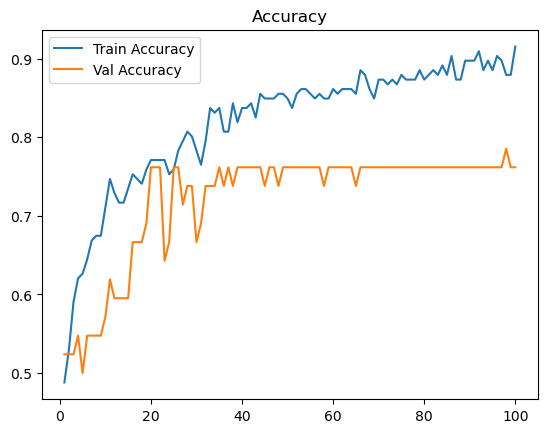

In [83]:
epochs = len(history.history['accuracy'])
plt.plot(range(1, epochs+1), history.history['accuracy'], label='Train Accuracy')
plt.plot(range(1, epochs+1), history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.legend()

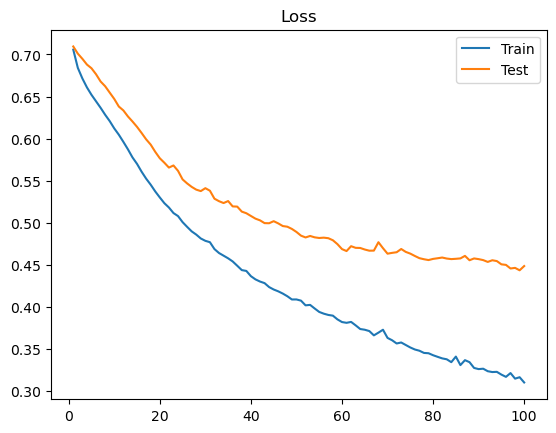

In [84]:
plt.plot(range(1, epochs+1),history.history['loss'],label='Train')
plt.plot(range(1, epochs+1),history.history['val_loss'],label='Test')
plt.title('Loss')
plt.legend()

In [85]:
## Evaluation for Default model

In [86]:
ypred_best=((best_model.predict(x_test))>0.5).astype(int)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step


In [87]:
acc_best = accuracy_score(y_test,ypred_best)
prec_best = precision_score(y_test,ypred_best)
rec_best= recall_score(y_test,ypred_best)
f1_best = f1_score(y_test,ypred_best)
print("Accuracy :", acc_best)
print("Precision:", prec_best)
print("Recall   :", rec_best)
print("F1-score :", f1_best)

Accuracy : 0.8571428571428571
Precision: 0.8333333333333334
Recall   : 0.9090909090909091
F1-score : 0.8695652173913043


In [88]:
print('\nClassification Report:\n',classification_report(y_test,ypred_best))


Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.80      0.84        20
           1       0.83      0.91      0.87        22

    accuracy                           0.86        42
   macro avg       0.86      0.85      0.86        42
weighted avg       0.86      0.86      0.86        42



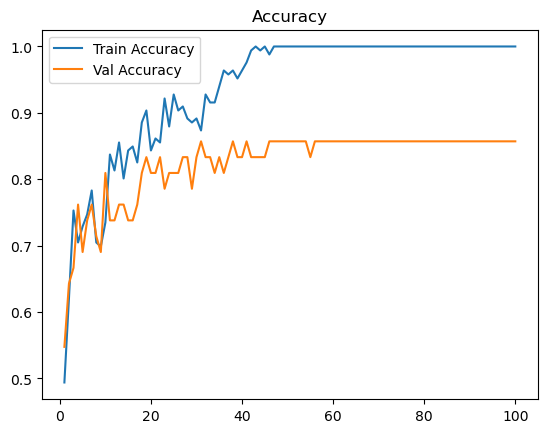

In [89]:
epochs = len(history_best.history['accuracy'])
plt.plot(range(1, epochs+1), history_best.history['accuracy'], label='Train Accuracy')
plt.plot(range(1, epochs+1), history_best.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.legend()

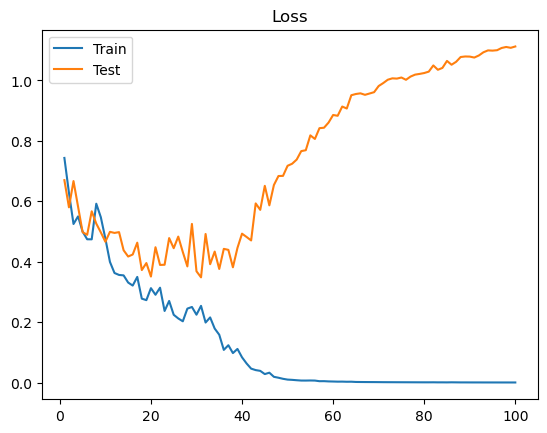

In [90]:
plt.plot(range(1, epochs+1),history_best.history['loss'],label='Train')
plt.plot(range(1, epochs+1),history_best.history['val_loss'],label='Test')
plt.title('Loss')
plt.legend()